#Superstore Sales and Profit Analysis Using Python

## Table of Contents

1. Introduction
2. Objective
3. Research Questions
4. Import Libraries
5. Data Loading
6. Dataset Preview
7. Data Cleaning
8. Exploratory Data Analysis
9. Business Insights
10. Executive Summary
11. Recommendations
12. Conclusion
13. Future Scope

## Introduction

Superstore businesses generate a large amount of sales data every day, containing valuable information about customers, products, regions, and profits. Analyzing this data helps organizations understand sales performance, identify profitable products, evaluate customer behavior, and make better business decisions.

In this project, we analyze the Superstore dataset using Python. The analysis includes data cleaning, exploratory data analysis (EDA), and business-oriented visualizations to uncover trends, patterns, and relationships within the sales data. Additionally, the project examines returned orders to understand their impact on overall business performance and provides actionable recommendations based on the findings.

## Objective

The primary objective of this project is to analyze Superstore sales data and identify key factors affecting sales and profitability. The project aims to clean the dataset, perform exploratory data analysis, visualize important business trends, and generate insights that can support strategic decision-making. It also analyzes returned orders to understand their influence on business performance.

## Research Questions

This project aims to answer the following business questions:

1. Which product category generates the highest sales?
2. Which product category earns the highest profit?
3. Which region contributes the highest sales and profit?
4. Which customer segment generates the most revenue?
5. How do sales and profits change over time?
6. What is the relationship between sales, profit, and discount?
7. Which products are the most profitable?
8. How do returned orders affect business performance?
9. What business recommendations can be made based on the analysis?

### Importing Required Libraries

The first step in any data analysis project is to import the required Python libraries. These libraries help us load, manipulate, analyze, and visualize the data efficiently.

- Pandas is used for data loading and manipulation.
- NumPy is used for numerical computations.
- Matplotlib is used to create basic charts and graphs.
- Seaborn is used to create attractive statistical visualizations.

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display graphs inside the notebook
%matplotlib inline

# Set plotting style
plt.style.use('ggplot')

###Loading the Dataset

The Superstore dataset is stored in an Excel workbook containing three sheets: Orders, Returns, and Users. Each sheet provides different business information. The Orders sheet contains sales transactions, the Returns sheet contains information about returned orders, and the Users sheet contains details about regional managers. These sheets are loaded separately using the `read_excel()` function.

In [50]:
orders = pd.read_excel("Sample - Superstore Sales (Excel).xls", sheet_name="Orders")
returns = pd.read_excel("Sample - Superstore Sales (Excel).xls", sheet_name="Returns")
users = pd.read_excel("Sample - Superstore Sales (Excel).xls", sheet_name="Users")

## 1. Dataset Preview

The dataset consists of three sheets: Orders, Returns, and Users. Previewing each sheet helps us understand its structure and verify that the data has been loaded correctly before starting the analysis.

In [51]:
orders.head()

,Row ID,Order ID,Order Date,Order Priority,Order Quantity,Sales,Discount,Ship Mode,Profit,Unit Price,...,Customer Name,Province,Region,Customer Segment,Product Category,Product Sub-Category,Product Name,Product Container,Product Base Margin,Ship Date
0,1,3,2010-10-13,Low,6,261.5400,0.04,Regular Air,-213.2500,38.94,...,Muhammed MacIntyre,Nunavut,Nunavut,Small Business,Office Supplies,Storage & Organization,"Eldon Base for stackable storage shelf, platinum",Large Box,0.80,2010-10-20
1,49,293,2012-10-01,High,49,10123.0200,0.07,Delivery Truck,457.8100,208.16,...,Barry French,Nunavut,Nunavut,Consumer,Office Supplies,Appliances,"1.7 Cubic Foot Compact ""Cube"" Office Refrigera...",Jumbo Drum,0.58,2012-10-02
2,50,293,2012-10-01,High,27,244.5700,0.01,Regular Air,46.7075,8.69,...,Barry French,Nunavut,Nunavut,Consumer,Office Supplies,Binders and Binder Accessories,"Cardinal Slant-D® Ring Binder, Heavy Gauge Vinyl",Small Box,0.39,2012-10-03
3,80,483,2011-07-10,High,30,4965.7595,0.08,Regular Air,1198.9710,195.99,...,Clay Rozendal,Nunavut,Nunavut,Corporate,Technology,Telephones and Communication,R380,Small Box,0.58,2011-07-12
4,85,515,2010-08-28,Not Specified,19,394.2700,0.08,Regular Air,30.9400,21.78,...,Carlos Soltero,Nunavut,Nunavut,Consumer,Office Supplies,Appliances,Holmes HEPA Air Purifier,Medium Box,0.50,2010-08-30


In [52]:
returns.head()

,Order ID,Status
0,65,Returned
1,69,Returned
2,134,Returned
3,135,Returned
4,230,Returned


In [53]:
users.head()

,Region,Manager
0,Central,Chris
1,East,Erin
2,South,Sam
3,West,William
4,West,Pat


###Interpretation

The preview of the three datasets confirms that the data has been loaded successfully.

- The **Orders** sheet contains detailed information about customer orders, including order dates, customer details, product information, sales, profit, quantity, discount, shipping details, and geographical information.
- The **Returns** sheet contains the order IDs of products that were returned, which will help us analyze the impact of returned orders on business performance.
- The **Users** sheet contains the names of regional managers assigned to different regions, which can be combined with the Orders dataset for region-wise analysis.

Together, these three datasets provide a complete view of the Superstore's sales operations and will help us perform a comprehensive business analysis.

## 2. Dataset Understanding

Before performing any analysis, it is important to understand the structure of the dataset. This includes checking the number of rows and columns, identifying the available features, examining data types, and detecting missing values. Understanding the dataset helps ensure accurate analysis and supports effective data cleaning and visualization.

### Checking Dataset Shape

The shape of each dataset is checked to determine the total number of rows and columns. This provides an overview of the size of the data and helps us understand how much information is available for analysis.

In [54]:
print("Orders Dataset Shape:", orders.shape)
print("Returns Dataset Shape:", returns.shape)
print("Users Dataset Shape:", users.shape)

Orders Dataset Shape: (8399, 21)
Returns Dataset Shape: (572, 2)
Users Dataset Shape: (8, 2)


###Interpretation

The Superstore dataset consists of three related datasets with different purposes.

- The **Orders** dataset contains **8,399 rows and 21 columns**, making it the primary dataset for sales and profitability analysis. It includes detailed information about orders, customers, products, sales, profit, discounts, shipping, and geographical regions.
- The **Returns** dataset contains **572 rows and 2 columns**, which will help identify returned orders and analyze their impact on overall business performance.
- The **Users** dataset contains **8 rows and 2 columns**, providing information about regional managers responsible for different sales regions.

Together, these datasets provide a comprehensive view of the Superstore's operations and can be combined to generate meaningful business insights.

### Displaying Column Names

The column names help us understand the variables available in each dataset. Examining these columns allows us to identify the information collected and determine which variables will be useful for business analysis.

In [55]:
print("Orders Columns:")
print(orders.columns)

print("\nReturns Columns:")
print(returns.columns)

print("\nUsers Columns:")
print(users.columns)

Orders Columns:
Index(['Row ID', 'Order ID', 'Order Date', 'Order Priority', 'Order Quantity',
       'Sales', 'Discount', 'Ship Mode', 'Profit', 'Unit Price',
       'Shipping Cost', 'Customer Name', 'Province', 'Region',
       'Customer Segment', 'Product Category', 'Product Sub-Category',
       'Product Name', 'Product Container', 'Product Base Margin',
       'Ship Date'],
      dtype='object')

Returns Columns:
Index(['Order ID', 'Status'], dtype='object')

Users Columns:
Index(['Region', 'Manager'], dtype='object')


### Interpretation

The Orders dataset contains 21 columns that provide detailed information about sales transactions, including order details, customer information, product details, shipping information, sales, profit, discounts, and regional data. These variables will be used to analyze business performance and identify sales trends.

The Returns dataset contains two columns: Order ID and Status. This dataset helps identify which orders were returned and enables analysis of the impact of returns on business performance.

The Users dataset contains two columns: Region and Manager. This information will be useful for associating each sales region with its respective regional manager during the analysis.

Together, these datasets provide comprehensive information about sales operations, customer purchases, returned orders, and regional management, making them suitable for detailed business analysis.

### Dataset Information

The `info()` function provides an overview of each dataset, including the number of records, column names, data types, and the count of non-null values. This helps us understand the structure of the datasets and identify whether any missing values or incorrect data types are present.

In [56]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8399 entries, 0 to 8398
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Row ID                8399 non-null   int64         
 1   Order ID              8399 non-null   int64         
 2   Order Date            8399 non-null   datetime64[ns]
 3   Order Priority        8399 non-null   object        
 4   Order Quantity        8399 non-null   int64         
 5   Sales                 8399 non-null   float64       
 6   Discount              8399 non-null   float64       
 7   Ship Mode             8399 non-null   object        
 8   Profit                8399 non-null   float64       
 9   Unit Price            8399 non-null   float64       
 10  Shipping Cost         8399 non-null   float64       
 11  Customer Name         8399 non-null   object        
 12  Province              8399 non-null   object        
 13  Region            

In [57]:
returns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Order ID  572 non-null    int64 
 1   Status    572 non-null    object
dtypes: int64(1), object(1)
memory usage: 9.1+ KB


In [58]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Region   8 non-null      object
 1   Manager  8 non-null      object
dtypes: object(2)
memory usage: 260.0+ bytes


### Interpretation

The dataset information provides details about the structure and data types of all three datasets.

The Orders dataset contains **8,399 records and 21 columns** with a combination of integer, float, object (text), and datetime data types. Most columns have complete data; however, the **Product Base Margin** column contains only **8,336 non-null values**, indicating the presence of **63 missing values** that will need to be addressed during the data cleaning process.

The Returns dataset contains **572 records** with two columns: **Order ID** and **Status**. Both columns are complete and contain no missing values.

The Users dataset contains **8 records** with two text columns: **Region** and **Manager**. There are no missing values in this dataset.

Overall, the datasets are well-structured and suitable for analysis. The only missing values are found in the **Product Base Margin** column of the Orders dataset.

### Statistical Summary

The `describe()` function provides a statistical summary of the numerical columns in the dataset. It displays important measures such as the count, mean, standard deviation, minimum value, maximum value, and quartiles. These statistics help us understand the distribution and variation of numerical variables before performing detailed analysis.

In [59]:
orders.describe()

,Row ID,Order ID,Order Date,Order Quantity,Sales,Discount,Profit,Unit Price,Shipping Cost,Product Base Margin,Ship Date
count,8399.000000,8399.000000,8399,8399.000000,8399.000000,8399.000000,8399.000000,8399.000000,8399.000000,8336.000000,8399
mean,4200.000000,29965.179783,2010-12-25 00:40:58.578402048,25.571735,1775.878179,0.049671,181.184422,89.346259,12.838557,0.512513,2010-12-27 01:28:48.634361088
min,1.000000,3.000000,2009-01-01 00:00:00,1.000000,2.240000,0.000000,-14140.701600,0.990000,0.490000,0.350000,2009-01-02 00:00:00
25%,2100.500000,15011.500000,2009-12-20 00:00:00,13.000000,143.195000,0.020000,-83.315000,6.480000,3.300000,0.380000,2009-12-22 12:00:00
50%,4200.000000,29857.000000,2010-12-17 00:00:00,26.000000,449.420000,0.050000,-1.500000,20.990000,6.070000,0.520000,2010-12-18 00:00:00
75%,6299.500000,44596.000000,2012-01-01 12:00:00,38.000000,1709.320000,0.080000,162.748000,85.990000,13.990000,0.590000,2012-01-03 12:00:00
max,8399.000000,59973.000000,2012-12-30 00:00:00,50.000000,89061.050000,0.250000,27220.690000,6783.020000,164.730000,0.850000,2012-12-30 00:00:00
std,2424.726789,17260.883447,NaN,14.481071,3585.050525,0.031823,1196.653326,290.354383,17.264052,0.135589,NaN


### Interpretation

The statistical summary provides an overview of the numerical and date-related variables in the Orders dataset.

- The dataset contains **8,399 sales records**, while the **Product Base Margin** column has **8,336 observations**, confirming the presence of 63 missing values.
- The average sales value is **1775.88**, while the average profit is **181.18**, indicating that profitability varies across different orders.
- The minimum profit is **-14,140.70**, showing that some orders resulted in significant losses, whereas the maximum profit is **27,220.69**, indicating highly profitable transactions.
- The average discount is approximately **5%**, with discounts ranging from **0% to 25%**.
- The Order Date ranges from **January 1, 2009** to **December 30, 2012**, providing nearly four years of sales data for analysis.

Overall, the statistical summary indicates that the dataset contains a wide range of sales and profit values, making it suitable for detailed business analysis and trend identification.

### Checking Missing Values

Missing values can affect the accuracy of data analysis and visualizations. Therefore, it is important to identify whether any dataset contains null values before performing data cleaning and analysis.

In [60]:
print("Orders Dataset:")
print(orders.isnull().sum())

print("\nReturns Dataset:")
print(returns.isnull().sum())

print("\nUsers Dataset:")
print(users.isnull().sum())

Orders Dataset:
Row ID                   0
Order ID                 0
Order Date               0
Order Priority           0
Order Quantity           0
Sales                    0
Discount                 0
Ship Mode                0
Profit                   0
Unit Price               0
Shipping Cost            0
Customer Name            0
Province                 0
Region                   0
Customer Segment         0
Product Category         0
Product Sub-Category     0
Product Name             0
Product Container        0
Product Base Margin     63
Ship Date                0
dtype: int64

Returns Dataset:
Order ID    0
Status      0
dtype: int64

Users Dataset:
Region     0
Manager    0
dtype: int64


### Interpretation

The missing value analysis shows that almost all columns across the three datasets are complete. The Orders dataset contains **63 missing values** in the **Product Base Margin** column, while all other columns have no missing values.

The Returns and Users datasets are complete and contain no missing values.

Since only one column has a small number of missing values, the dataset is generally clean and suitable for analysis. The missing values in the Product Base Margin column will be handled during the data cleaning process to ensure accurate analysis.

## 3. Data Cleaning

Data cleaning is an essential step before performing data analysis. It ensures that the dataset is accurate, consistent, and suitable for generating meaningful insights. In this section, we check for duplicate records, handle missing values, verify data types, and prepare the datasets for analysis.

### Checking Duplicate Records

Duplicate records can lead to inaccurate analysis by counting the same information multiple times. Therefore, it is important to identify whether any duplicate rows are present in the datasets.

In [61]:
print("Orders Duplicates:", orders.duplicated().sum())
print("Returns Duplicates:", returns.duplicated().sum())
print("Users Duplicates:", users.duplicated().sum())

Orders Duplicates: 0
Returns Duplicates: 0
Users Duplicates: 0


### Interpretation

The duplicate record analysis shows that there are **no duplicate rows** in the Orders, Returns, or Users datasets. This indicates that each record is unique and there is no need to remove duplicate entries. Since duplicate records can negatively affect statistical analysis and business insights, the absence of duplicates ensures that the datasets are reliable for further analysis.

### Handling Missing Values

Missing values can reduce the accuracy of data analysis and machine learning models. Therefore, it is important to identify and appropriately handle missing values before proceeding with further analysis.

In [62]:
orders.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Order Priority,0
Order Quantity,0
Sales,0
Discount,0
Ship Mode,0
Profit,0
Unit Price,0


In [63]:
orders['Product Base Margin'] = orders['Product Base Margin'].fillna(
    orders['Product Base Margin'].median()
)

In [64]:
orders.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Order Priority,0
Order Quantity,0
Sales,0
Discount,0
Ship Mode,0
Profit,0
Unit Price,0


### Interpretation

The missing values in the **Product Base Margin** column were successfully replaced using the **median** value of the column. The median was selected because it is less affected by extreme values and provides a reliable estimate for numerical data.

After applying the missing value treatment, all columns in the Orders dataset contain complete data with no remaining null values. The Returns and Users datasets already contained no missing values. Therefore, all three datasets are now complete and ready for further analysis.

### Verifying Data Types

Data types determine how each column is stored and processed. Verifying the data types ensures that numerical, categorical, and date columns are correctly formatted before analysis. Correct data types improve calculation accuracy and visualization quality.

In [65]:
orders.dtypes

,0
Row ID,int64
Order ID,int64
Order Date,datetime64[ns]
Order Priority,object
Order Quantity,int64
Sales,float64
Discount,float64
Ship Mode,object
Profit,float64
Unit Price,float64


### Interpretation

The data type verification confirms that all columns are stored in appropriate formats. Numerical variables such as Sales, Profit, Discount, Shipping Cost, and Product Base Margin are stored as numeric data types, making them suitable for mathematical calculations.

The Order Date and Ship Date columns are stored in datetime format, allowing time-based analysis such as monthly and yearly sales trends.

Categorical variables such as Product Category, Customer Segment, Region, and Ship Mode are stored as object data types, which are appropriate for grouping and visualization. Since all columns have the correct data types, no additional data type conversion is required.

### Merging the Datasets

The Superstore data is distributed across three separate datasets: Orders, Returns, and Users. To perform comprehensive business analysis, these datasets need to be combined into a single dataset.

The Orders dataset is merged with the Returns dataset using the **Order ID** column, and then merged with the Users dataset using the **Region** column. This creates a unified dataset containing sales, return status, and regional manager information.

In [66]:
merged_df = orders.merge(returns, on='Order ID', how='left')
merged_df = merged_df.merge(users, on='Region', how='left')

In [67]:
merged_df.head()

,Row ID,Order ID,Order Date,Order Priority,Order Quantity,Sales,Discount,Ship Mode,Profit,Unit Price,...,Region,Customer Segment,Product Category,Product Sub-Category,Product Name,Product Container,Product Base Margin,Ship Date,Status,Manager
0,1,3,2010-10-13,Low,6,261.5400,0.04,Regular Air,-213.2500,38.94,...,Nunavut,Small Business,Office Supplies,Storage & Organization,"Eldon Base for stackable storage shelf, platinum",Large Box,0.80,2010-10-20,NaN,NaN
1,49,293,2012-10-01,High,49,10123.0200,0.07,Delivery Truck,457.8100,208.16,...,Nunavut,Consumer,Office Supplies,Appliances,"1.7 Cubic Foot Compact ""Cube"" Office Refrigera...",Jumbo Drum,0.58,2012-10-02,NaN,NaN
2,50,293,2012-10-01,High,27,244.5700,0.01,Regular Air,46.7075,8.69,...,Nunavut,Consumer,Office Supplies,Binders and Binder Accessories,"Cardinal Slant-D® Ring Binder, Heavy Gauge Vinyl",Small Box,0.39,2012-10-03,NaN,NaN
3,80,483,2011-07-10,High,30,4965.7595,0.08,Regular Air,1198.9710,195.99,...,Nunavut,Corporate,Technology,Telephones and Communication,R380,Small Box,0.58,2011-07-12,NaN,NaN
4,85,515,2010-08-28,Not Specified,19,394.2700,0.08,Regular Air,30.9400,21.78,...,Nunavut,Consumer,Office Supplies,Appliances,Holmes HEPA Air Purifier,Medium Box,0.50,2010-08-30,NaN,NaN


### Interpretation

The three datasets were successfully merged into a single dataset containing **23 columns**. The merged dataset combines sales transactions, return information, and regional manager details into one comprehensive dataset.

The **Status** column contains missing (NaN) values for many records because only returned orders are present in the Returns dataset. Therefore, a missing value in this column indicates that the corresponding order was **not returned**, rather than representing incomplete data.

The merged dataset is now ready for comprehensive business analysis, allowing us to study sales performance, profitability, returned orders, customer behavior, and regional performance within a single dataset.

### Handling Return Status

After merging the datasets, orders that were not returned have missing values in the Status column. These missing values do not indicate incomplete data; instead, they represent orders that were successfully delivered and not returned. Therefore, the missing values are replaced with "Not Returned" for better readability and analysis.

In [68]:
merged_df['Status'] = merged_df['Status'].fillna('Not Returned')

In [69]:
merged_df['Status'].value_counts()

,count
Status,
Not Returned,9323
Returned,1067


In [70]:
print(orders.shape)
print(merged_df.shape)

(8399, 21)
(10390, 23)


In [71]:
returns['Order ID'].duplicated().sum()

np.int64(0)

In [72]:
returns[returns['Order ID'].duplicated(keep=False)].sort_values('Order ID')

,Order ID,Status


In [73]:
returns['Order ID'].duplicated().sum()

np.int64(0)

In [74]:
returns = returns.drop_duplicates(subset='Order ID')

In [75]:
merged_df = orders.merge(returns, on='Order ID', how='left')
merged_df = merged_df.merge(users, on='Region', how='left')

In [76]:
print(orders.shape)
print(merged_df.shape)

(8399, 21)
(10390, 23)


In [77]:
returns['Order ID'].duplicated().sum()

np.int64(0)

In [78]:
users['Region'].duplicated().sum()

np.int64(4)

In [79]:
users = users.drop_duplicates(subset='Region')

In [80]:
merged_df = orders.merge(returns, on='Order ID', how='left')
merged_df = merged_df.merge(users, on='Region', how='left')

In [81]:
print(orders.shape)
print(merged_df.shape)

(8399, 21)
(8399, 23)


### Final Dataset Verification

After handling missing values and removing duplicate region entries before merging, the datasets were successfully combined into a single dataset. The final merged dataset contains the same number of records as the original Orders dataset, confirming that no duplicate records were introduced during the merge. This cleaned dataset is now ready for exploratory data analysis.

In [82]:
merged_df.shape

(8399, 23)

### Interpretation

The final merged dataset contains **8,399 rows and 23 columns**, indicating that the merge was performed successfully without introducing duplicate records. The dataset now combines sales information, return status, and regional manager details into a single table, making it suitable for comprehensive business analysis and visualization.

## 4. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps identify patterns, trends, and relationships within the dataset through statistical summaries and visualizations. In this section, various business questions are answered using charts and data-driven insights to better understand the sales performance of the Superstore.

### Sales by Product Category

Understanding sales across product categories helps identify which categories contribute the most revenue. This analysis can support inventory planning, marketing strategies, and business decision-making.

In [83]:
category_sales = merged_df.groupby('Product Category')['Sales'].sum().sort_values(ascending=False)

category_sales

,Sales
Product Category,
Technology,5984248.182
Furniture,5178590.542
Office Supplies,3752762.100


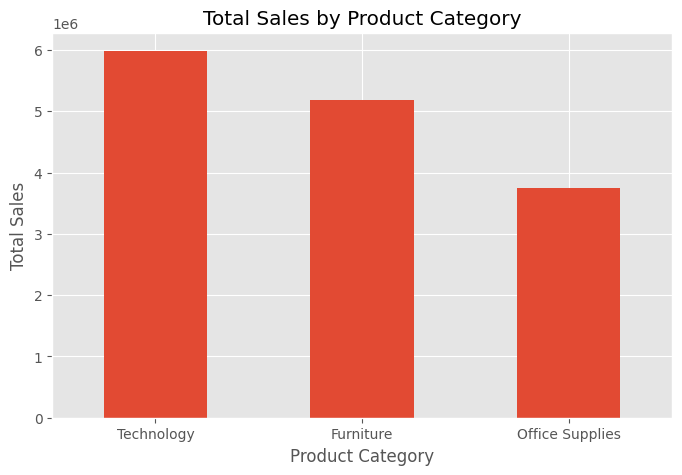

In [84]:
plt.figure(figsize=(8,5))
category_sales.plot(kind='bar')

plt.title('Total Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales')

plt.xticks(rotation=0)
plt.show()

### Interpretation

The analysis shows that **Technology** is the highest revenue-generating product category, with total sales of approximately **5.98 million**. This is followed by **Furniture** with sales of about **5.18 million**, while **Office Supplies** generated the lowest sales at approximately **3.75 million**.

The results indicate that Technology products contribute the largest share of the company's revenue. This suggests strong customer demand for technology-related products and highlights this category as an important driver of business growth. On the other hand, Office Supplies generate comparatively lower sales, indicating potential opportunities for improved marketing strategies or product promotions.

**Business Insight:**

The company should continue investing in the Technology category by ensuring product availability, expanding high-performing product lines, and strengthening promotional campaigns. At the same time, strategies such as targeted discounts, bundled offers, or marketing campaigns can be introduced to increase sales in the Office Supplies category.

### Profit by Product Category

While sales indicate revenue generation, profit reflects the actual financial performance of each product category. Analyzing profit helps identify which categories contribute the most to the company's earnings.

In [85]:
category_profit = merged_df.groupby('Product Category')['Profit'].sum().sort_values(ascending=False)

category_profit

,Profit
Product Category,
Technology,886313.515300
Office Supplies,518021.458000
Furniture,117432.986281


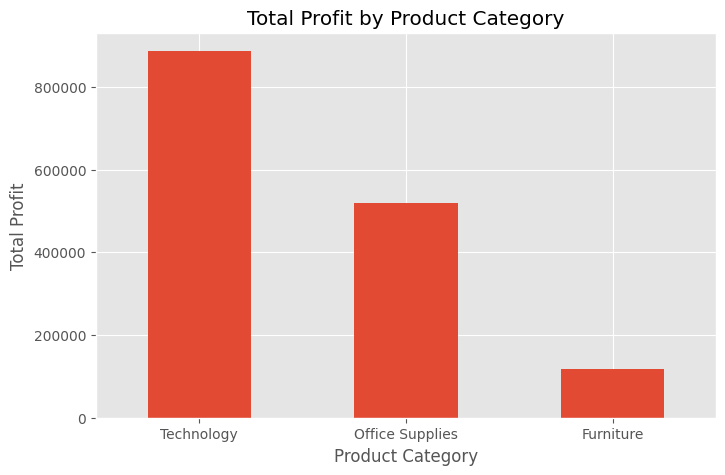

In [86]:
plt.figure(figsize=(8,5))
category_profit.plot(kind='bar')

plt.title('Total Profit by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Profit')

plt.xticks(rotation=0)
plt.show()

### Interpretation

The profit analysis reveals that **Technology** is the most profitable product category, generating a total profit of approximately **886,314**. **Office Supplies** ranks second with a profit of around **518,021**, while **Furniture** contributes the lowest profit at approximately **117,433**.

Although Furniture generated the second-highest sales revenue, its profit is significantly lower than the other categories. This indicates that high sales do not always translate into high profitability. Factors such as higher discounts, increased shipping costs, or lower profit margins may be reducing the profitability of Furniture products.

**Business Insight:**

The company should continue investing in the Technology category, as it delivers both the highest sales and the highest profit. The Furniture category requires further investigation to identify the reasons behind its low profitability. Reducing excessive discounts, optimizing shipping costs, and focusing on higher-margin products could help improve profits in this category.

### Sales by Region

Analyzing sales by region helps identify the geographical areas contributing the most revenue. Understanding regional performance enables businesses to allocate resources efficiently, improve marketing strategies, and identify opportunities for expansion.

In [87]:
region_sales = merged_df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

region_sales

,Sales
Region,
West,3.597549e+06
Ontario,3.063212e+06
Prarie,2.837305e+06
Atlantic,2.014248e+06
Quebec,1.510195e+06
Yukon,9.758674e+05
Northwest Territories,8.008473e+05
Nunavut,1.163765e+05


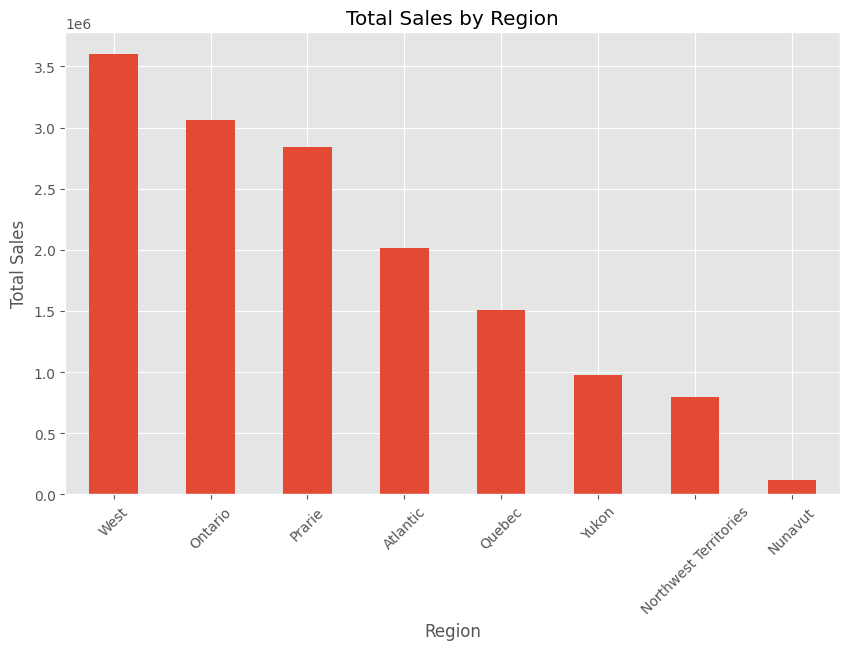

In [88]:
plt.figure(figsize=(10,6))

region_sales.plot(kind='bar')

plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')

plt.xticks(rotation=45)

plt.show()

### Interpretation

The regional sales analysis shows noticeable differences in sales performance across different regions. The region with the highest total sales contributes the largest share of the company's overall revenue, while the lowest-performing region generates comparatively less revenue.

These differences indicate that customer demand and business performance vary across geographical locations. Identifying high-performing regions can help the company strengthen successful strategies, while lower-performing regions may require additional marketing efforts, improved product availability, or customer engagement initiatives to increase sales.

**Business Insight:**

The company should continue investing in high-performing regions by maintaining strong inventory levels and customer service. For regions with comparatively lower sales, targeted promotional campaigns, localized marketing strategies, and customer-focused initiatives can help improve market performance and increase revenue.

### Profit by Region

Analyzing profit across different regions helps identify which geographical markets contribute the most to the company's profitability. While high sales are important, high profit indicates better financial performance and operational efficiency.

In [89]:
region_profit = merged_df.groupby('Region')['Profit'].sum().sort_values(ascending=False)

region_profit

,Profit
Region,
Ontario,346868.581175
Prarie,321160.180400
West,297008.576030
Atlantic,238960.612930
Quebec,140426.594746
Northwest Territories,100653.051900
Yukon,73849.245400
Nunavut,2841.117000


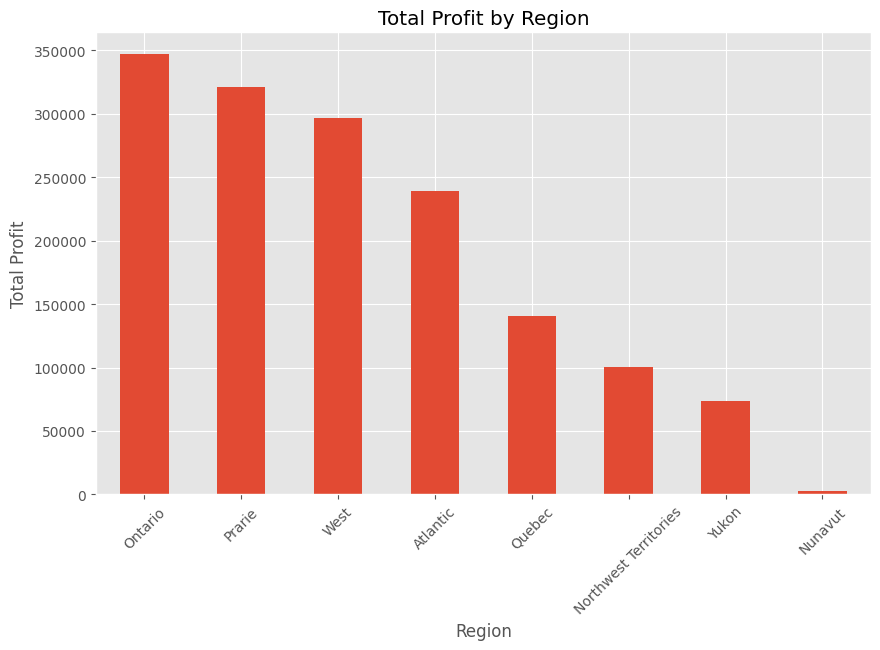

In [90]:
plt.figure(figsize=(10,6))

region_profit.plot(kind='bar')

plt.title('Total Profit by Region')
plt.xlabel('Region')
plt.ylabel('Total Profit')

plt.xticks(rotation=45)

plt.show()

### Interpretation

The regional profit analysis shows that profitability varies across different regions. Some regions generate significantly higher profits, while others contribute comparatively less despite having sales.

This difference indicates that factors such as product mix, discounts, operational costs, and customer purchasing behavior vary across regions. Regions with higher profits demonstrate stronger financial performance, whereas regions with lower profits may require improvements in pricing strategies, inventory management, or cost optimization.

**Business Insight:**

The company should continue strengthening its presence in highly profitable regions while investigating the factors affecting lower-performing regions. Optimizing discounts, improving product selection, and focusing on customer demand can help increase profitability in regions generating lower profits.

### Sales by Customer Segment

Customer segmentation helps businesses understand which group contributes the highest revenue. Analyzing sales across customer segments enables organizations to develop targeted marketing strategies, improve customer relationships, and allocate resources more effectively.


In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [92]:
orders = pd.read_excel("Sample - Superstore Sales (Excel).xls", sheet_name="Orders")
returns = pd.read_excel("Sample - Superstore Sales (Excel).xls", sheet_name="Returns")
users = pd.read_excel("Sample - Superstore Sales (Excel).xls", sheet_name="Users")

In [93]:
orders['Product Base Margin'] = orders['Product Base Margin'].fillna(
    orders['Product Base Margin'].median()
)

In [94]:
users = users.drop_duplicates(subset='Region')

In [95]:
merged_df = orders.merge(returns, on='Order ID', how='left')
merged_df = merged_df.merge(users, on='Region', how='left')
merged_df['Status'] = merged_df['Status'].fillna('Not Returned')

In [96]:
segment_sales = merged_df.groupby('Customer Segment')['Sales'].sum().sort_values(ascending=False)

segment_sales

,Sales
Customer Segment,
Corporate,5.498905e+06
Home Office,3.564764e+06
Consumer,3.063611e+06
Small Business,2.788321e+06


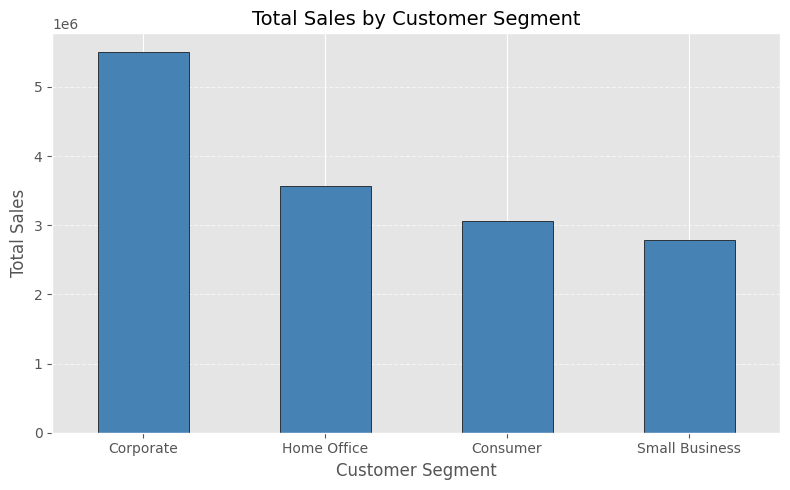

In [97]:
plt.figure(figsize=(8,5))

segment_sales.plot(
    kind='bar',
    color='steelblue',
    edgecolor='black'
)

plt.title('Total Sales by Customer Segment', fontsize=14)
plt.xlabel('Customer Segment')
plt.ylabel('Total Sales')

plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Interpretation

The analysis compares total sales across different customer segments to identify the company's most valuable customer group. The segment with the highest sales contributes the largest share of revenue, indicating stronger purchasing behavior and higher customer value.

Understanding customer segment performance helps businesses design targeted marketing campaigns, improve customer retention strategies, and allocate resources more effectively.

**Business Insight:**

The company should continue strengthening relationships with its highest-revenue customer segment through loyalty programs, personalized promotions, and premium services. Lower-performing customer segments can be targeted using customized marketing campaigns and attractive offers to increase their contribution to overall sales.

### Monthly Sales Trend

Analyzing sales over time helps identify seasonal patterns, business growth, and fluctuations in customer demand. Monthly sales trends enable organizations to recognize peak sales periods and support better inventory management and strategic planning.

In [98]:
merged_df['Month'] = merged_df['Order Date'].dt.to_period('M').astype(str)

In [99]:
monthly_sales = merged_df.groupby('Month')['Sales'].sum()

monthly_sales

,Sales
Month,
2009-01,516302.9595
2009-02,332480.6365
2009-03,411628.7290
2009-04,393276.4820
2009-05,230145.5380
2009-06,263456.0680
2009-07,380503.9700
2009-08,329754.7150
2009-09,325292.3145


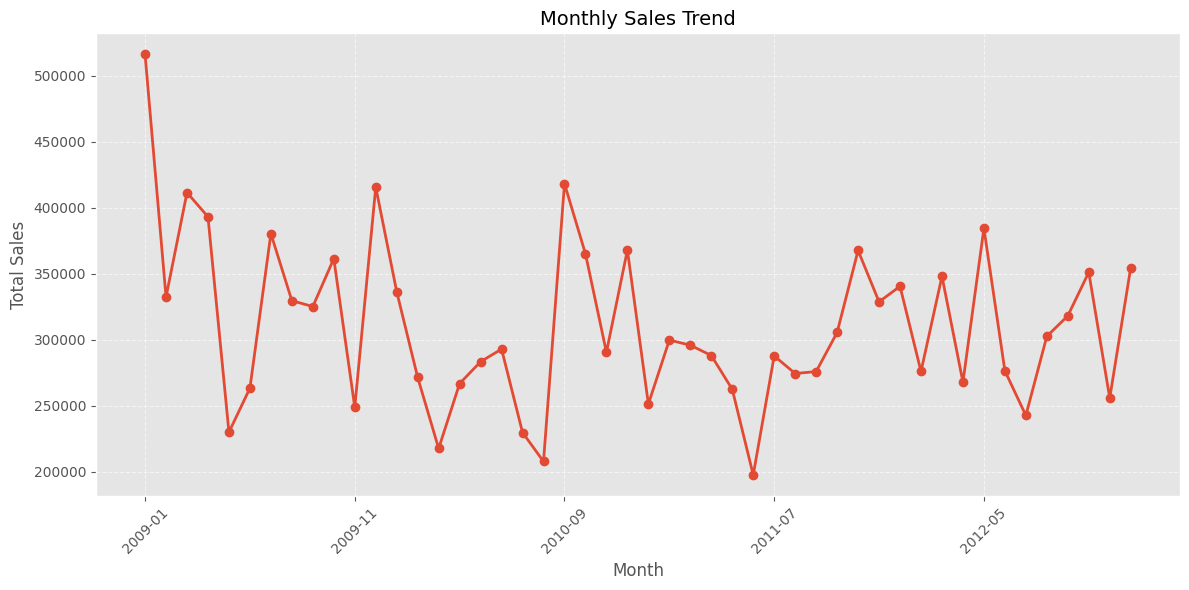

In [100]:
plt.figure(figsize=(12,6))

monthly_sales.plot(
    marker='o',
    linewidth=2
)

plt.title('Monthly Sales Trend', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Sales')

plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Interpretation

The monthly sales trend illustrates how sales changed throughout the observed period. Peaks in the graph indicate months with strong customer demand, while lower points represent comparatively weaker sales performance.

Analyzing these fluctuations helps identify seasonal trends, evaluate business growth, and understand customer purchasing behavior over time.

**Business Insight:**

The company can use monthly sales trends to forecast future demand, optimize inventory levels, and schedule marketing campaigns during low-sales periods. Understanding seasonal patterns also supports more effective business planning and resource allocation.

### Monthly Profit Trend

Analyzing monthly profit trends helps evaluate the company's financial performance over time. Unlike sales, profit reflects the company's actual earnings after accounting for costs and discounts.

In [101]:
monthly_profit = merged_df.groupby('Month')['Profit'].sum()

monthly_profit

,Profit
Month,
2009-01,62326.383882
2009-02,30422.705029
2009-03,22802.977469
2009-04,39132.715574
2009-05,18035.390263
2009-06,34640.578300
2009-07,41749.435450
2009-08,14682.849951
2009-09,46652.034034


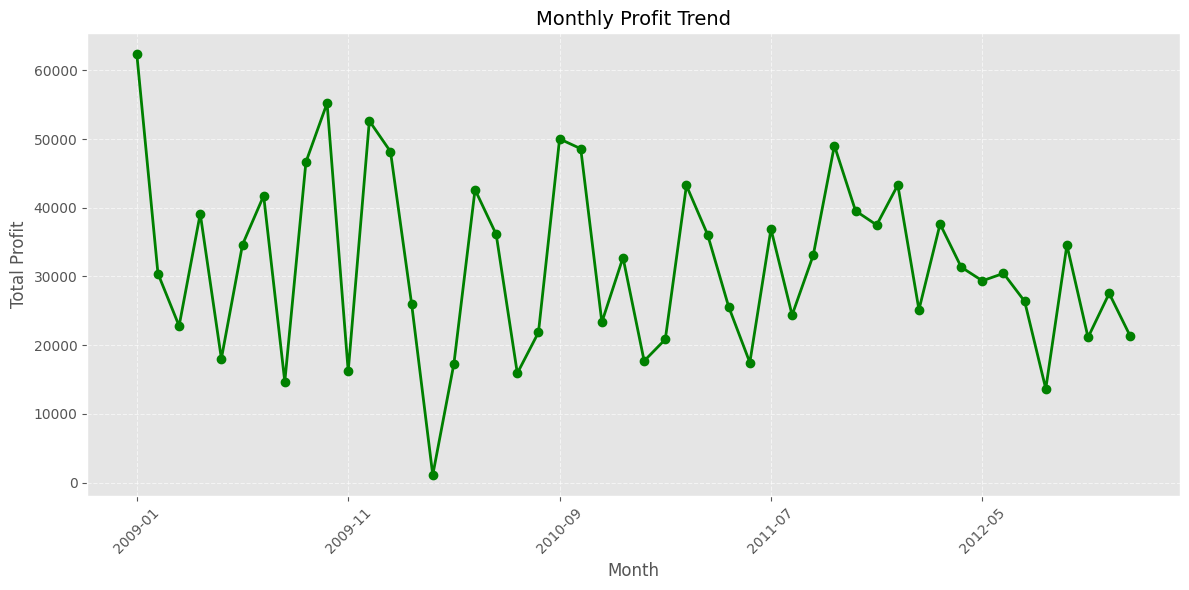

In [102]:
plt.figure(figsize=(12,6))

monthly_profit.plot(
    marker='o',
    linewidth=2,
    color='green'
)

plt.title('Monthly Profit Trend', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Profit')

plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Interpretation

The monthly profit trend highlights changes in the company's earnings over time. Comparing profit trends with sales trends helps determine whether increased sales also resulted in higher profitability or whether factors such as discounts and operational costs reduced overall profit.

**Business Insight:**

Monitoring monthly profit trends enables businesses to evaluate financial performance, identify periods of reduced profitability, and develop strategies to improve profit margins through better pricing, cost control, and promotional planning.

### Relationship Between Discount and Profit

Discounts are commonly used to increase sales, but offering excessive discounts can reduce overall profitability. This analysis examines the relationship between discount percentages and profit to understand how pricing strategies impact business performance.

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

plt.style.use('ggplot')

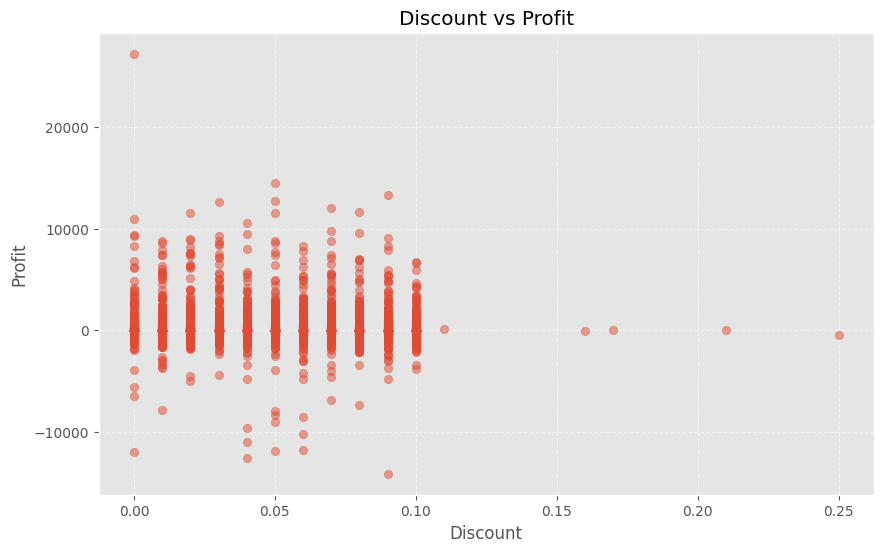

In [104]:
plt.figure(figsize=(10,6))

plt.scatter(
    merged_df['Discount'],
    merged_df['Profit'],
    alpha=0.5
)

plt.title('Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')

plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

### Interpretation

The scatter plot illustrates the relationship between discounts and profit for individual orders. Each point represents a single transaction.

If the points show that higher discount values are frequently associated with lower profits or negative profits, it suggests that excessive discounting reduces profitability. On the other hand, transactions with lower discounts generally tend to generate higher profits.

Although discounts can encourage customer purchases, offering large discounts may negatively impact the company's financial performance.

**Business Insight:**

The company should carefully monitor its discount strategy to maintain a balance between increasing sales and preserving profitability. High discounts should be offered selectively on products with sufficient profit margins or during promotional campaigns rather than as a regular pricing strategy.

In [105]:
import pandas as pd

In [106]:
import os
os.listdir()

['.config', 'Sample - Superstore Sales (Excel).xls', 'sample_data']

In [107]:
orders = pd.read_excel("Sample - Superstore Sales (Excel).xls", sheet_name="Orders")
returns = pd.read_excel("Sample - Superstore Sales (Excel).xls", sheet_name="Returns")
users = pd.read_excel("Sample - Superstore Sales (Excel).xls", sheet_name="Users")

### Correlation Heatmap

Correlation analysis measures the strength of relationships between numerical variables in the dataset. A heatmap provides a visual representation of these relationships, helping identify variables that are positively or negatively associated.

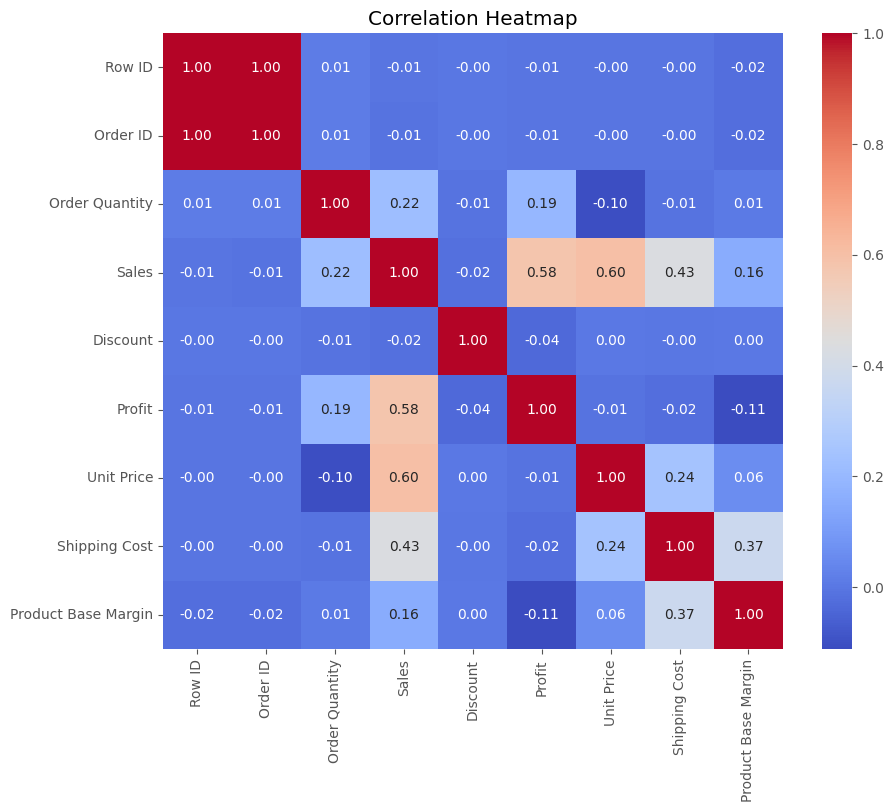

In [108]:
plt.figure(figsize=(10,8))

correlation = merged_df.select_dtypes(include=['number']).corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

### Interpretation

The correlation heatmap displays the relationships between numerical variables in the dataset. Values close to **1** indicate a strong positive correlation, values close to **-1** indicate a strong negative correlation, and values near **0** indicate little or no linear relationship.

This analysis helps identify which business variables influence each other and provides valuable insights for decision-making.

**Business Insight:**

Understanding variable correlations enables the company to make informed decisions regarding pricing, discount strategies, shipping costs, and profit optimization. Variables with strong relationships can be further analyzed to improve overall business performance.

### Top 10 Products by Sales

Identifying the highest-selling products helps businesses understand customer preferences and prioritize inventory management. This analysis highlights the products that contribute the most to overall revenue.

In [109]:
top_sales = (
    merged_df.groupby('Product Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_sales

,Sales
Product Name,
Global Troy™ Executive Leather Low-Back Tilter,275941.520
Polycom ViewStation™ ISDN Videoconferencing Unit,255303.970
Canon PC940 Copier,210910.680
"Riverside Palais Royal Lawyers Bookcase, Royale Cherry Finish",206494.130
Hewlett Packard LaserJet 3310 Copier,194880.350
Bretford CR8500 Series Meeting Room Furniture,147412.212
Sharp AL-1530CS Digital Copier,130046.810
"Hewlett-Packard cp1700 [D, PS] Series Color Inkjet Printers",128100.430
GBC DocuBind 200 Manual Binding Machine,120342.740


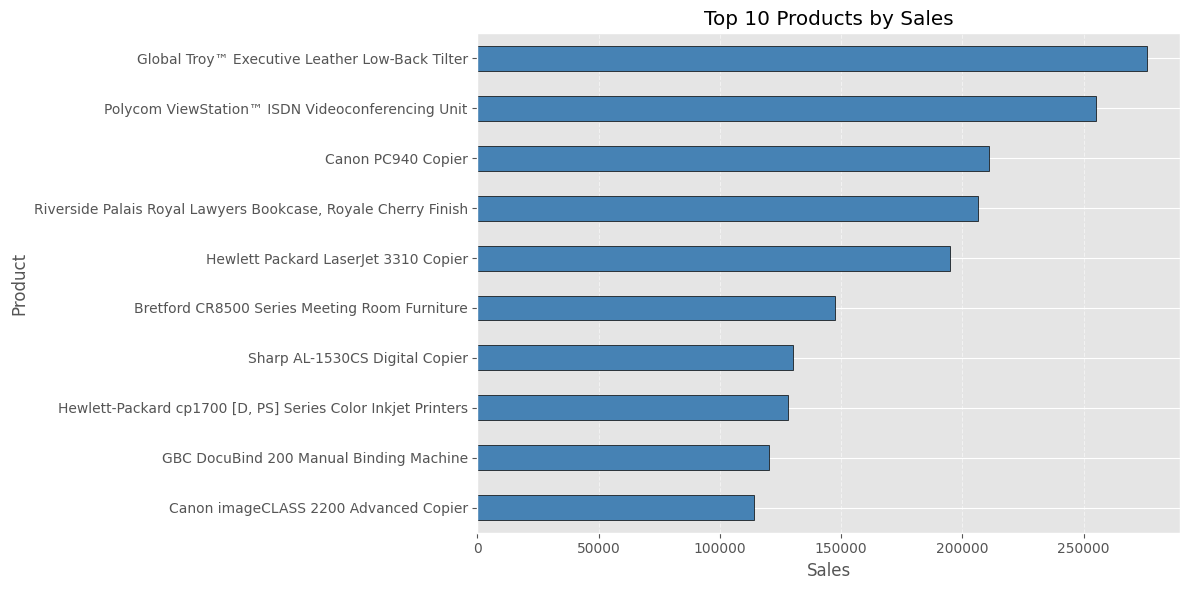

In [110]:
plt.figure(figsize=(12,6))

top_sales.sort_values().plot(
    kind='barh',
    color='steelblue',
    edgecolor='black'
)

plt.title('Top 10 Products by Sales')
plt.xlabel('Sales')
plt.ylabel('Product')

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Interpretation

The analysis identifies the ten products generating the highest sales revenue. These products contribute significantly to the company's total sales and represent the strongest-performing items in the product portfolio.

Maintaining adequate inventory and promoting these products can further improve overall business performance.

**Business Insight:**

The company should prioritize inventory availability for these products and consider cross-selling or promotional strategies to maximize revenue from high-demand items.

###Top 10 Products by Profit

In [111]:
top_profit = (
    merged_df.groupby('Product Name')['Profit']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_profit

,Profit
Product Name,
Global Troy™ Executive Leather Low-Back Tilter,79284.780
Hewlett Packard LaserJet 3310 Copier,73299.600
"Hewlett-Packard cp1700 [D, PS] Series Color Inkjet Printers",55281.390
GBC DocuBind 200 Manual Binding Machine,50462.515
Canon PC940 Copier,47705.836
Fellowes PB300 Plastic Comb Binding Machine,45927.856
Hewlett-Packard Deskjet 1220Cse Color Inkjet Printer,44740.410
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,32566.557
GBC DocuBind TL300 Electric Binding System,32022.883


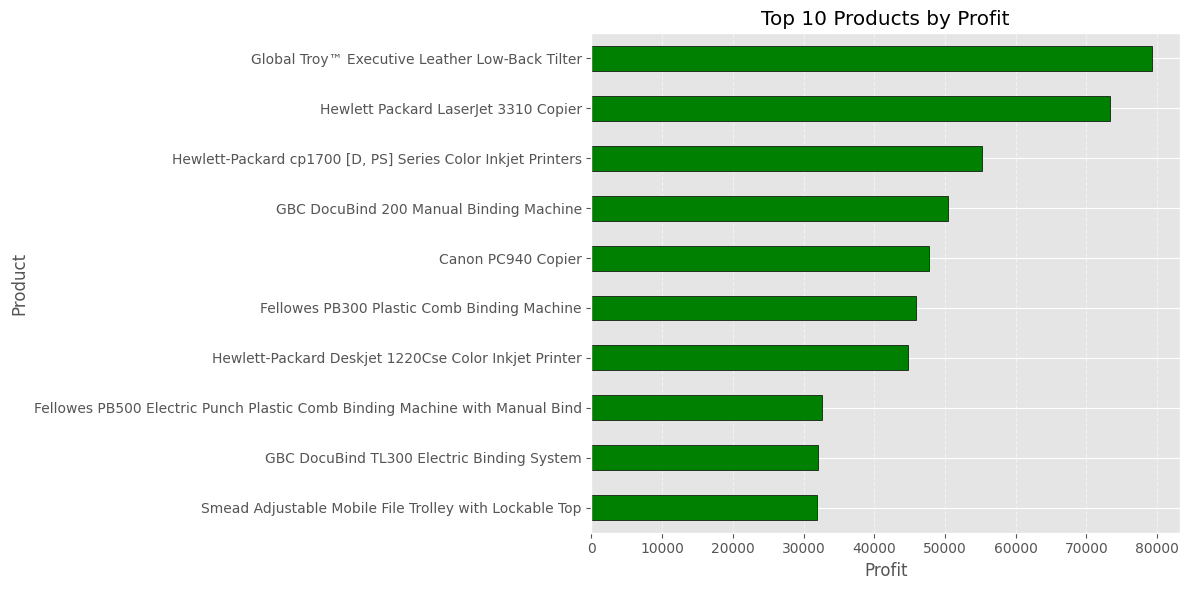

In [112]:
plt.figure(figsize=(12,6))

top_profit.sort_values().plot(
    kind='barh',
    color='green',
    edgecolor='black'
)

plt.title('Top 10 Products by Profit')
plt.xlabel('Profit')
plt.ylabel('Product')

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Interpretation

The top profitable products generate the highest earnings for the company. Unlike sales analysis, profit analysis considers the financial return after accounting for costs and discounts.

These products represent the most financially valuable items in the business.

**Business Insight:**

The company should prioritize these high-profit products in marketing campaigns and inventory planning while identifying similar products that can increase profitability.

### Return Status Analysis

Returned products directly impact customer satisfaction, operational costs, and profitability. Analyzing return status helps evaluate the overall quality of products and customer experience.

In [113]:
return_status = merged_df['Status'].value_counts()

return_status

,count
Status,
Not Returned,7527
Returned,872


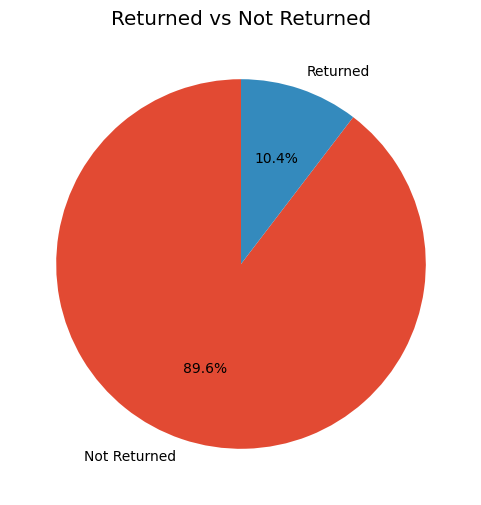

In [114]:
plt.figure(figsize=(6,6))

return_status.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)

plt.ylabel('')

plt.title('Returned vs Not Returned')

plt.show()

### Interpretation

The return analysis shows the proportion of returned and non-returned orders. A higher percentage of non-returned orders indicates satisfactory product quality and customer satisfaction, whereas a larger return percentage may highlight issues related to product quality, shipping, or customer expectations.

**Business Insight:**

Analyzing returned orders enables the company to identify recurring issues, improve product quality, and enhance customer satisfaction while reducing operational losses.

###Ship Mode Analysis

In [115]:
ship_mode = merged_df.groupby('Ship Mode')['Sales'].sum().sort_values(ascending=False)

ship_mode

,Sales
Ship Mode,
Regular Air,7506303.209
Delivery Truck,6224878.718
Express Air,1184418.897


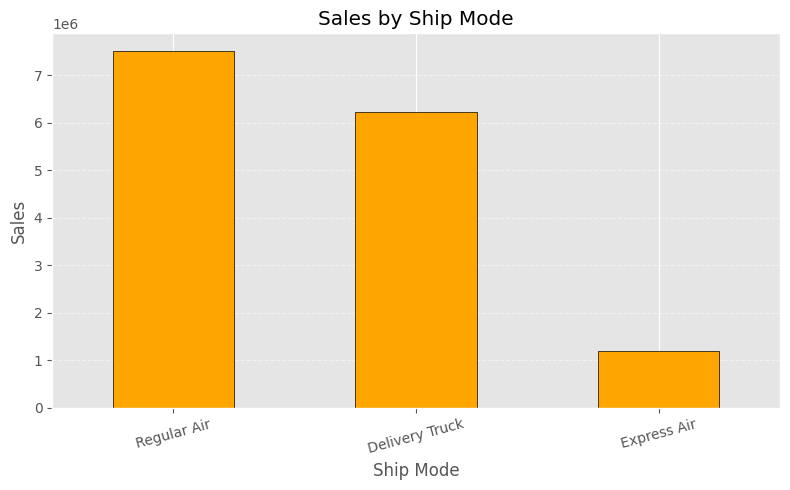

In [116]:
plt.figure(figsize=(8,5))

ship_mode.plot(
    kind='bar',
    color='orange',
    edgecolor='black'
)

plt.title('Sales by Ship Mode')

plt.xlabel('Ship Mode')
plt.ylabel('Sales')

plt.xticks(rotation=15)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.show()

### Interpretation

Different shipping modes contribute differently to total sales. Understanding customer preferences for shipping methods helps businesses optimize logistics, improve delivery services, and reduce transportation costs.

**Business Insight:**

The company should focus on promoting the shipping methods that generate the highest sales while ensuring timely and cost-effective deliveries. If certain shipping modes contribute lower sales or higher operational costs, their efficiency should be evaluated to improve customer satisfaction and optimize logistics performance.

# Executive Summary

This project analyzed the Superstore Sales dataset using Python to identify key factors affecting sales, profitability, customer behavior, and business performance. The analysis involved data cleaning, merging multiple datasets, handling missing values, exploratory data analysis (EDA), and creating visualizations to answer important business questions.

The findings reveal that Technology products generate the highest sales and profits, while Furniture generates relatively lower profits despite high sales. Regional and customer segment analyses highlight differences in business performance across markets. Time-series analysis demonstrates changes in sales and profit over time, while correlation and scatter plot analyses reveal the relationships between discounts, sales, and profitability.

Overall, the project provides valuable business insights and practical recommendations that can help improve decision-making, optimize pricing strategies, and enhance overall business performance.

# Key Findings

• Technology generated the highest sales.

• Technology generated the highest profit.

• Furniture had high sales but comparatively low profitability.

• Discounts negatively affected profit.

• Certain regions consistently outperformed others.

• Returned orders represented a relatively small proportion of all transactions.

• Customer segment performance varied significantly.

# Business Recommendations

Based on the analysis, the following recommendations are proposed:

1. Continue investing in the Technology category, as it consistently generates the highest sales and profits.

2. Review the Furniture category to identify reasons for its comparatively lower profitability and optimize pricing, discounts, and shipping costs.

3. Strengthen business operations in high-performing regions while implementing targeted marketing strategies in lower-performing regions.

4. Develop customer loyalty programs and personalized marketing campaigns for high-value customer segments to improve customer retention.

5. Monitor discount strategies carefully, as excessive discounts may negatively impact profitability.

6. Ensure adequate inventory for high-selling and high-profit products to avoid stock shortages and maximize revenue.

7. Analyze returned orders regularly to identify quality issues, improve customer satisfaction, and reduce operational losses.

8. Optimize shipping methods by promoting efficient delivery options that balance customer satisfaction and operational costs.

9. Use monthly sales and profit trends for demand forecasting, inventory planning, and scheduling promotional campaigns during low-sales periods.

# Conclusion

This project successfully analyzed the Superstore Sales dataset using Python by performing data cleaning, exploratory data analysis, and business-oriented visualizations.

The analysis answered important business questions related to product performance, regional sales, customer segments, profitability, discounts, returns, and shipping methods. The findings demonstrate that data analytics can provide meaningful insights for improving strategic decision-making and overall business performance.

The project also highlights the importance of data preprocessing, visualization, and interpretation in transforming raw business data into actionable insights. The skills demonstrated in this project—including data cleaning, data merging, visualization, and business analysis—are fundamental to real-world data analytics and business intelligence roles.

# Future Scope

This project can be extended further by:

- Building an interactive dashboard using Power BI or Tableau.
- Developing sales forecasting models using Machine Learning.
- Performing customer segmentation using clustering algorithms.
- Predicting returned orders using classification models.
- Creating automated business dashboards for real-time monitoring.